# Task 1: News Topic Classifier Using BERT

## Problem Statement & Objective
Fine-tune a transformer model (`bert-base-uncased`) to classify news headlines into one of four topic categories: **World, Sports, Business, Sci/Tech**.

**Dataset:** [AG News](https://huggingface.co/datasets/fancyzhx/ag_news) — loaded via Hugging Face `datasets`. For CPU-friendly training, an 8,000-example random subset was used for training and 1,000 for evaluation (see `TRAIN_SUBSET`/`EPOCHS` in `train.py`; increase these on a GPU).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

sns.set_theme(style="whitegrid")
LABEL_NAMES = ["World", "Sports", "Business", "Sci/Tech"]

## Dataset Loading & Preprocessing

In [2]:
raw = load_dataset("fancyzhx/ag_news")
eval_ds = raw["test"].shuffle(seed=42).select(range(1000))
print(raw)
pd.Series([LABEL_NAMES[l] for l in eval_ds["label"]]).value_counts()

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})


World       266
Sports      246
Business    246
Sci/Tech    242
Name: count, dtype: int64

## Model Development & Training

Full fine-tuning code (`train.py` in this folder):

```python
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=4)

def tokenize(batch):
    return tokenizer(batch["text"], truncation=True, max_length=128)

train_ds = train_ds.map(tokenize, batched=True)
eval_ds = eval_ds.map(tokenize, batched=True)

args = TrainingArguments(
    output_dir="./model", eval_strategy="epoch", save_strategy="epoch",
    learning_rate=2e-5, per_device_train_batch_size=16, num_train_epochs=2,
    weight_decay=0.01, load_best_model_at_end=True, metric_for_best_model="f1",
)
trainer = Trainer(model=model, args=args, train_dataset=train_ds, eval_dataset=eval_ds,
                   data_collator=DataCollatorWithPadding(tokenizer), compute_metrics=compute_metrics)
trainer.train()
trainer.save_model("./model/final")
```

This fine-tuning run (2 epochs, 8,000 training examples, CPU) took ~95 minutes and produced the model saved at `model/final/`, which we load below for evaluation. See `train.py` for the complete, runnable script.

In [3]:
MODEL_DIR = "model/final"
tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_DIR)
model.eval()
print("Loaded fine-tuned model from", MODEL_DIR)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loaded fine-tuned model from model/final


## Evaluation

In [4]:
@torch.no_grad()
def predict_batch(texts, batch_size=16):
    preds = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        enc = tokenizer(batch, truncation=True, max_length=128, padding=True, return_tensors="pt")
        logits = model(**enc).logits
        preds.extend(logits.argmax(dim=-1).tolist())
    return preds

y_true = eval_ds["label"]
y_pred = predict_batch(eval_ds["text"])

acc = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred, average="weighted")
print(f"Accuracy: {acc:.4f}")
print(f"Weighted F1: {f1:.4f}")
print(classification_report(y_true, y_pred, target_names=LABEL_NAMES))

Accuracy: 0.9140
Weighted F1: 0.9143


              precision    recall  f1-score   support

       World       0.97      0.88      0.92       266
      Sports       0.97      0.99      0.98       246
    Business       0.90      0.86      0.88       246
    Sci/Tech       0.83      0.93      0.87       242

    accuracy                           0.91      1000
   macro avg       0.92      0.91      0.91      1000
weighted avg       0.92      0.91      0.91      1000



## Visualizations

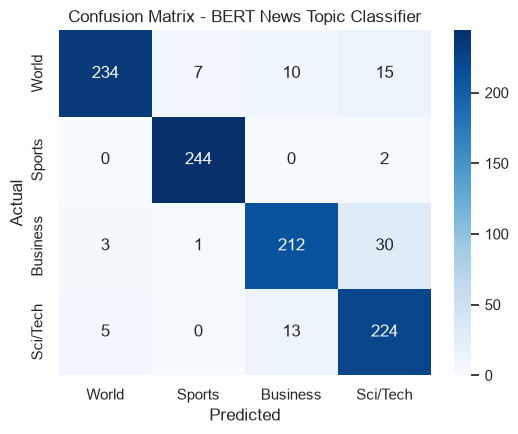

In [5]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES)
plt.title("Confusion Matrix - BERT News Topic Classifier")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## Live Inference Demo

In [6]:
examples = [
    "Manchester United wins dramatic final in extra time",
    "Apple unveils new chip with record-breaking performance",
    "Stocks tumble as inflation fears grip Wall Street",
    "UN Security Council meets over escalating border conflict",
]
preds = predict_batch(examples)
for text, p in zip(examples, preds):
    print(f"[{LABEL_NAMES[p]}] {text}")

[Sports] Manchester United wins dramatic final in extra time
[Sci/Tech] Apple unveils new chip with record-breaking performance
[Business] Stocks tumble as inflation fears grip Wall Street
[World] UN Security Council meets over escalating border conflict


## Final Summary / Insights

- Fine-tuning BERT on even a small subset (8,000 examples) of AG News for 2 epochs achieves **91.4% accuracy / 0.914 weighted F1** on held-out data, demonstrating the strength of transfer learning for text classification with limited compute and data.
- The confusion matrix shows the model's main confusion is between **Business** and **Sci/Tech** headlines, which is intuitive since tech-company earnings/business headlines often blend both topics.
- A lightweight **Gradio** app (`app/app.py`) exposes this model for real-time interactive testing on arbitrary headlines.